In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv('amazon_bestsellers.csv')
df.head()

,Name,Author,User_Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8.0,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22.0,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15.0,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6.0,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12.0,2019,Non Fiction


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         550 non-null    object 
 1   Author       550 non-null    object 
 2   User_Rating  550 non-null    float64
 3   Reviews      550 non-null    int64  
 4   Price        538 non-null    float64
 5   Year         550 non-null    int64  
 6   Genre        550 non-null    object 
dtypes: float64(2), int64(2), object(3)
memory usage: 30.2+ KB


In [34]:
df.describe()

,User_Rating,Reviews,Price,Year
count,550.000000,550.000000,538.000000,550.000000
mean,4.618364,11953.281818,13.392193,2014.000000
std,0.226980,11731.132017,10.782447,3.165156
min,3.300000,37.000000,1.000000,2009.000000
25%,4.500000,4058.000000,7.000000,2011.000000
50%,4.700000,8580.000000,11.000000,2014.000000
75%,4.800000,17253.250000,16.000000,2017.000000
max,4.900000,87841.000000,105.000000,2019.000000


In [35]:
df[df['Price'].isnull()]

,Name,Author,User_Rating,Reviews,Price,Year,Genre
42,"Cabin Fever (Diary of a Wimpy Kid, Book 6)",Jeff Kinney,4.8,4505,NaN,2011,Fiction
71,"Diary of a Wimpy Kid: Hard Luck, Book 8",Jeff Kinney,4.8,6812,NaN,2013,Fiction
116,Frozen (Little Golden Book),RH Disney,4.7,3642,NaN,2014,Fiction
193,JOURNEY TO THE ICE P,RH Disney,4.6,978,NaN,2014,Fiction
219,Little Blue Truck,Alice Schertle,4.9,1884,NaN,2014,Fiction
358,The Constitution of the United States,Delegates of the Constitutional,4.8,2774,NaN,2016,Non Fiction
381,The Getaway,Jeff Kinney,4.8,5836,NaN,2017,Fiction
461,The Short Second Life of Bree Tanner: An Eclip...,Stephenie Meyer,4.6,2122,NaN,2010,Fiction
505,To Kill a Mockingbird,Harper Lee,4.8,26234,NaN,2013,Fiction
506,To Kill a Mockingbird,Harper Lee,4.8,26234,NaN,2014,Fiction


In [36]:
#1. Delete Row/Columns with NULL Values

#df[df['Price'].isnull()==False].info()

df.dropna()

# Pro: easy to perform/quick
# Con: indiscriminate in its use


,Name,Author,User_Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8.0,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22.0,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15.0,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6.0,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12.0,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8.0,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8.0,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8.0,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8.0,2018,Non Fiction


In [27]:
#2.(if needing to convert missing values to Null Values) 

df = df.replace(' ',np.nan)


In [28]:
df[df['Price'].isnull()]

,Name,Author,User_Rating,Reviews,Price,Year,Genre
42,"Cabin Fever (Diary of a Wimpy Kid, Book 6)",Jeff Kinney,4.8,4505,NaN,2011,Fiction
71,"Diary of a Wimpy Kid: Hard Luck, Book 8",Jeff Kinney,4.8,6812,NaN,2013,Fiction
116,Frozen (Little Golden Book),RH Disney,4.7,3642,NaN,2014,Fiction
193,JOURNEY TO THE ICE P,RH Disney,4.6,978,NaN,2014,Fiction
219,Little Blue Truck,Alice Schertle,4.9,1884,NaN,2014,Fiction
358,The Constitution of the United States,Delegates of the Constitutional,4.8,2774,NaN,2016,Non Fiction
381,The Getaway,Jeff Kinney,4.8,5836,NaN,2017,Fiction
461,The Short Second Life of Bree Tanner: An Eclip...,Stephenie Meyer,4.6,2122,NaN,2010,Fiction
505,To Kill a Mockingbird,Harper Lee,4.8,26234,NaN,2013,Fiction
506,To Kill a Mockingbird,Harper Lee,4.8,26234,NaN,2014,Fiction


In [29]:
#3 Fill NULL value with Average/Median/Mode (or use other dataset)

mean_price = np.mean(df['Price'])

df['Price'] = df['Price'].fillna(mean_price) 

In [41]:
df_avg_price_year = df[['Year','Price']].groupby('Year', as_index=False)['Price'].mean()
df_avg_price_year = df_avg_price_year.rename(columns={'Price': 'Avg_Price_Year'})
df_avg_price_year

,Year,Avg_Price_Year
0,2009,15.400000
1,2010,13.755102
2,2011,15.408163
3,2012,15.300000
4,2013,15.208333
5,2014,15.913043
6,2015,10.632653
7,2016,13.729167
8,2017,11.612245
9,2018,10.520000


In [42]:
df = df.merge(df_avg_price_year, on = 'Year')
df['Price'] = df['Price'].fillna(df['Avg_Price_Year'])
df

,Name,Author,User_Rating,Reviews,Price,Year,Genre,Avg_Price_Year_x,Avg_Price_Year_y,Avg_Price_Year
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8.0,2016,Non Fiction,13.729167,13.729167,13.729167
1,11/22/63: A Novel,Stephen King,4.6,2052,22.0,2011,Fiction,15.408163,15.408163,15.408163
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15.0,2018,Non Fiction,10.520000,10.520000,10.520000
3,1984 (Signet Classics),George Orwell,4.7,21424,6.0,2017,Fiction,11.612245,11.612245,11.612245
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12.0,2019,Non Fiction,10.080000,10.080000,10.080000
...,...,...,...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8.0,2019,Fiction,10.080000,10.080000,10.080000
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8.0,2016,Non Fiction,13.729167,13.729167,13.729167
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8.0,2017,Non Fiction,11.612245,11.612245,11.612245
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8.0,2018,Non Fiction,10.520000,10.520000,10.520000


In [43]:
df[df['Price'].isnull()]

,Name,Author,User_Rating,Reviews,Price,Year,Genre,Avg_Price_Year_x,Avg_Price_Year_y,Avg_Price_Year


# 1: Which Author Has the Most Best Sellers?

In [45]:
df_author_book_count = df.groupby(['Author']).count()['Year']
df_author_book_count = df_author_book_count.sort_values(ascending=False)
df_author_book_count = df_author_book_count[:10]
df_author_book_count

Author
Jeff Kinney                           12
Gary Chapman                          11
Suzanne Collins                       11
Rick Riordan                          11
American Psychological Association    10
Gallup                                 9
Dr. Seuss                              9
Rob Elliott                            8
Eric Carle                             7
Bill O'Reilly                          7
Name: Year, dtype: int64

In [46]:
df[df['Author']=='Gary Chapman']

,Name,Author,User_Rating,Reviews,Price,Year,Genre,Avg_Price_Year_x,Avg_Price_Year_y,Avg_Price_Year
320,The 5 Love Languages: The Secret to Love That ...,Gary Chapman,4.7,3477,28.0,2010,Non Fiction,13.755102,13.755102,13.755102
321,The 5 Love Languages: The Secret to Love That ...,Gary Chapman,4.7,3477,28.0,2011,Non Fiction,15.408163,15.408163,15.408163
322,The 5 Love Languages: The Secret to Love That ...,Gary Chapman,4.7,3477,28.0,2012,Non Fiction,15.300000,15.300000,15.300000
323,The 5 Love Languages: The Secret to Love That ...,Gary Chapman,4.7,3477,28.0,2013,Non Fiction,15.208333,15.208333,15.208333
324,The 5 Love Languages: The Secret to Love That ...,Gary Chapman,4.7,3477,28.0,2014,Non Fiction,15.913043,15.913043,15.913043
325,The 5 Love Languages: The Secret to Love that ...,Gary Chapman,4.8,25554,8.0,2015,Non Fiction,10.632653,10.632653,10.632653
326,The 5 Love Languages: The Secret to Love that ...,Gary Chapman,4.8,25554,8.0,2016,Non Fiction,13.729167,13.729167,13.729167
327,The 5 Love Languages: The Secret to Love that ...,Gary Chapman,4.8,25554,8.0,2017,Non Fiction,11.612245,11.612245,11.612245
328,The 5 Love Languages: The Secret to Love that ...,Gary Chapman,4.8,25554,8.0,2018,Non Fiction,10.520000,10.520000,10.520000
329,The 5 Love Languages: The Secret to Love that ...,Gary Chapman,4.8,25554,8.0,2019,Non Fiction,10.080000,10.080000,10.080000


In [47]:
df_unique = df.drop_duplicates(subset=['Name', 'Author'])
df_unique 

,Name,Author,User_Rating,Reviews,Price,Year,Genre,Avg_Price_Year_x,Avg_Price_Year_y,Avg_Price_Year
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8.0,2016,Non Fiction,13.729167,13.729167,13.729167
1,11/22/63: A Novel,Stephen King,4.6,2052,22.0,2011,Fiction,15.408163,15.408163,15.408163
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15.0,2018,Non Fiction,10.520000,10.520000,10.520000
3,1984 (Signet Classics),George Orwell,4.7,21424,6.0,2017,Fiction,11.612245,11.612245,11.612245
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12.0,2019,Non Fiction,10.080000,10.080000,10.080000
...,...,...,...,...,...,...,...,...,...,...
538,Winter of the World: Book Two of the Century T...,Ken Follett,4.5,10760,15.0,2012,Fiction,15.300000,15.300000,15.300000
539,Women Food and God: An Unexpected Path to Almo...,Geneen Roth,4.2,1302,11.0,2010,Non Fiction,13.755102,13.755102,13.755102
540,Wonder,R. J. Palacio,4.8,21625,9.0,2013,Fiction,15.208333,15.208333,15.208333
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8.0,2019,Fiction,10.080000,10.080000,10.080000


In [48]:
df_author_book_count = df_unique.groupby(['Author']).count()['Year']
df_author_book_count = df_author_book_count.sort_values(ascending=False)
df_author_book_count = df_author_book_count[:10]
df_author_book_count

Author
Jeff Kinney        12
Rick Riordan       10
Stephenie Meyer     7
J.K. Rowling        6
Bill O'Reilly       6
Dav Pilkey          6
E L James           5
John Grisham        5
Suzanne Collins     5
Stephen King        4
Name: Year, dtype: int64

# 2: Which Book was a top 50 best seller for most years?

In [54]:
df_years_bestseller  = df[['Name', 'Year']].groupby('Name', as_index=False).count()
df_years_bestseller

,Name,Year
0,10-Day Green Smoothie Cleanse,1
1,11/22/63: A Novel,1
2,12 Rules for Life: An Antidote to Chaos,1
3,1984 (Signet Classics),1
4,"5,000 Awesome Facts (About Everything!) (Natio...",1
...,...,...
346,Winter of the World: Book Two of the Century T...,1
347,Women Food and God: An Unexpected Path to Almo...,1
348,Wonder,5
349,Wrecking Ball (Diary of a Wimpy Kid Book 14),1


In [55]:
df_years_bestseller = df_years_bestseller.sort_values('Year', ascending=False)[:10]
df_years_bestseller

,Name,Year
191,Publication Manual of the American Psychologic...,10
209,StrengthsFinder 2.0,9
178,"Oh, the Places You'll Go!",8
310,The Very Hungry Caterpillar,7
219,The 7 Habits of Highly Effective People: Power...,7
243,The Four Agreements: A Practical Guide to Pers...,6
140,Jesus Calling: Enjoying Peace in His Presence ...,6
281,The Official SAT Study Guide,5
322,To Kill a Mockingbird,5
216,The 5 Love Languages: The Secret to Love That ...,5


In [ ]:
# 3. Which fiction Books were in the top 50 best seller for the most years?

In [58]:
df_fiction = df[df['Genre']=='Fiction']
df_fiction

,Name,Author,User_Rating,Reviews,Price,Year,Genre,Avg_Price_Year_x,Avg_Price_Year_y,Avg_Price_Year
1,11/22/63: A Novel,Stephen King,4.6,2052,22.0,2011,Fiction,15.408163,15.408163,15.408163
3,1984 (Signet Classics),George Orwell,4.7,21424,6.0,2017,Fiction,11.612245,11.612245,11.612245
5,A Dance with Dragons (A Song of Ice and Fire),George R. R. Martin,4.4,12643,11.0,2011,Fiction,15.408163,15.408163,15.408163
6,A Game of Thrones / A Clash of Kings / A Storm...,George R. R. Martin,4.7,19735,30.0,2014,Fiction,15.913043,15.913043,15.913043
7,A Gentleman in Moscow: A Novel,Amor Towles,4.7,19699,15.0,2017,Fiction,11.612245,11.612245,11.612245
...,...,...,...,...,...,...,...,...,...,...
541,Wonder,R. J. Palacio,4.8,21625,9.0,2014,Fiction,15.913043,15.913043,15.913043
542,Wonder,R. J. Palacio,4.8,21625,9.0,2015,Fiction,10.632653,10.632653,10.632653
543,Wonder,R. J. Palacio,4.8,21625,9.0,2016,Fiction,13.729167,13.729167,13.729167
544,Wonder,R. J. Palacio,4.8,21625,9.0,2017,Fiction,11.612245,11.612245,11.612245


In [61]:
df_fiction_bestseller  = df_fiction[['Name', 'Year']].groupby('Name', as_index=False).count()
df_fiction_bestseller

,Name,Year
0,11/22/63: A Novel,1
1,1984 (Signet Classics),1
2,A Dance with Dragons (A Song of Ice and Fire),1
3,A Game of Thrones / A Clash of Kings / A Storm...,1
4,A Gentleman in Moscow: A Novel,1
...,...,...
155,Where the Crawdads Sing,1
156,Where the Wild Things Are,1
157,Winter of the World: Book Two of the Century T...,1
158,Wonder,5


In [62]:
df_fiction_ten_bestseller = df_fiction_bestseller.sort_values('Year', ascending=False)[:10]
df_fiction_ten_bestseller

,Name,Year
72,"Oh, the Places You'll Go!",8
142,The Very Hungry Caterpillar,7
44,Giraffes Can't Dance,5
158,Wonder,5
146,To Kill a Mockingbird,5
112,The Help,4
143,The Wonderful Things You Will Be,4
97,The Fault in Our Stars,4
19,Dear Zoo: A Lift-the-Flap Book,4
13,Catching Fire (The Hunger Games),3


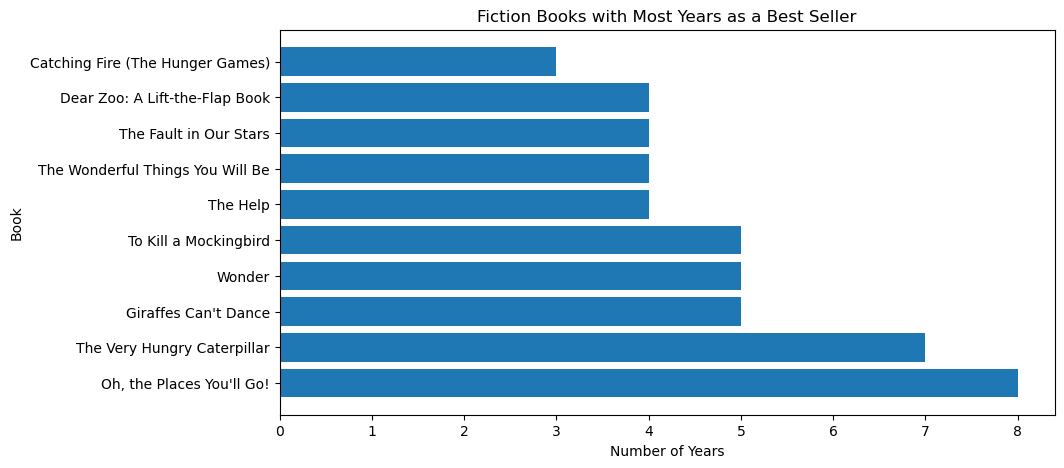

In [67]:
fig, ax = plt.subplots(figsize=(10,5))
plt.barh(df_fiction_ten_bestseller['Name'], df_fiction_ten_bestseller['Year'])

plt.title('Fiction Books with Most Years as a Best Seller')
plt.xlabel('Number of Years')
plt.ylabel('Book')
plt.show()

## 4. Which book has the most reviews?

In [69]:
df_unique.sort_values('Reviews',ascending=False)[:10]

,Name,Author,User_Rating,Reviews,Price,Year,Genre,Avg_Price_Year_x,Avg_Price_Year_y,Avg_Price_Year
534,Where the Crawdads Sing,Delia Owens,4.8,87841,15.0,2019,Fiction,10.080000,10.080000,10.080000
382,The Girl on the Train,Paula Hawkins,4.1,79446,18.0,2015,Fiction,10.632653,10.632653,10.632653
32,Becoming,Michelle Obama,4.8,61133,11.0,2018,Non Fiction,10.520000,10.520000,10.520000
135,Gone Girl,Gillian Flynn,4.0,57271,10.0,2012,Fiction,15.300000,15.300000,15.300000
365,The Fault in Our Stars,John Green,4.7,50482,13.0,2012,Fiction,15.300000,15.300000,15.300000
437,The Nightingale: A Novel,Kristin Hannah,4.8,49288,11.0,2015,Fiction,10.632653,10.632653,10.632653
106,Fifty Shades of Grey: Book One of the Fifty Sh...,E L James,3.8,47265,14.0,2012,Fiction,15.300000,15.300000,15.300000
433,The Martian,Andy Weir,4.7,39459,9.0,2015,Fiction,10.632653,10.632653,10.632653
20,All the Light We Cannot See,Anthony Doerr,4.6,36348,14.0,2014,Fiction,15.913043,15.913043,15.913043
338,The Alchemist,Paulo Coelho,4.7,35799,39.0,2014,Fiction,15.913043,15.913043,15.913043


## 5. Which book has the greatest review count each year?

In [72]:
max_reviews_per_year = df.groupby('Year', as_index=False)['Reviews'].max()
max_reviews_per_year

,Year,Reviews
0,2009,19720
1,2010,32122
2,2011,32122
3,2012,57271
4,2013,57271
5,2014,57271
6,2015,79446
7,2016,79446
8,2017,29442
9,2018,61133


In [74]:
pd.merge(df, max_reviews_per_year, on = ['Year', 'Reviews'], how = 'inner').sort_values('Year')

,Name,Author,User_Rating,Reviews,Price,Year,Genre,Avg_Price_Year_x,Avg_Price_Year_y,Avg_Price_Year
9,The Shack: Where Tragedy Confronts Eternity,William P. Young,4.6,19720,8.0,2009,Fiction,15.400000,15.400000,15.400000
7,The Hunger Games,Suzanne Collins,4.7,32122,14.0,2010,Fiction,13.755102,13.755102,13.755102
8,The Hunger Games (Book 1),Suzanne Collins,4.7,32122,8.0,2011,Fiction,15.408163,15.408163,15.408163
1,Gone Girl,Gillian Flynn,4.0,57271,10.0,2012,Fiction,15.300000,15.300000,15.300000
2,Gone Girl,Gillian Flynn,4.0,57271,10.0,2013,Fiction,15.208333,15.208333,15.208333
3,Gone Girl,Gillian Flynn,4.0,57271,9.0,2014,Fiction,15.913043,15.913043,15.913043
4,The Girl on the Train,Paula Hawkins,4.1,79446,18.0,2015,Fiction,10.632653,10.632653,10.632653
5,The Girl on the Train,Paula Hawkins,4.1,79446,7.0,2016,Fiction,13.729167,13.729167,13.729167
6,The Handmaid's Tale,Margaret Atwood,4.3,29442,7.0,2017,Fiction,11.612245,11.612245,11.612245
0,Becoming,Michelle Obama,4.8,61133,11.0,2018,Non Fiction,10.520000,10.520000,10.520000


## 6. Book price and rating trend over time

In [91]:
df_year_avg_price_rating = df[['Year','Price','User_Rating']].groupby(['Year']).mean().reset_index()
df_year_avg_price_rating = df_year_avg_price_rating.sort_values('Year')
df_year_avg_price_rating

,Year,Price,User_Rating
0,2009,15.400000,4.584
1,2010,13.755102,4.558
2,2011,15.408163,4.558
3,2012,15.300000,4.532
4,2013,15.208333,4.554
5,2014,15.913043,4.622
6,2015,10.632653,4.648
7,2016,13.729167,4.678
8,2017,11.612245,4.660
9,2018,10.520000,4.668


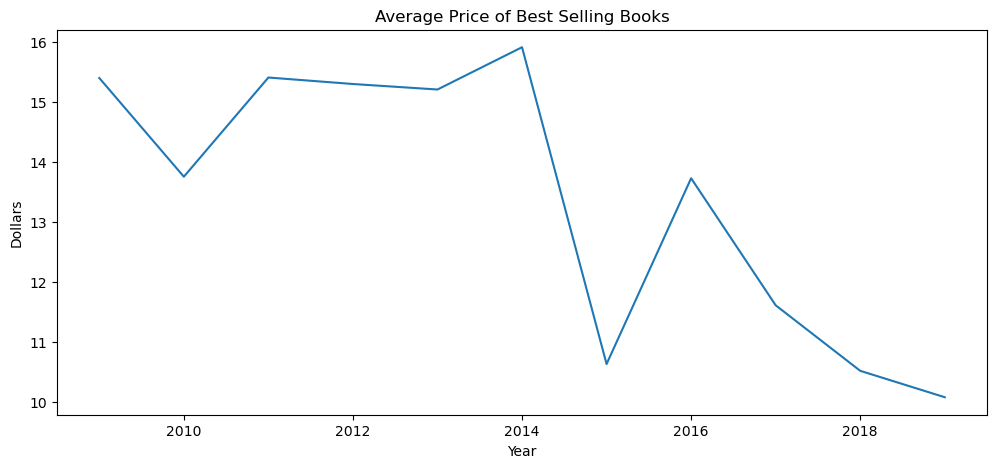

In [93]:
fig, ax = plt.subplots(figsize=(12,5))
plt.plot(df_year_avg_price_rating['Year'], df_year_avg_price_rating['Price'])
plt.title('Average Price of Best Selling Books')
plt.xlabel('Year')
plt.ylabel('Dollars')
plt.show()

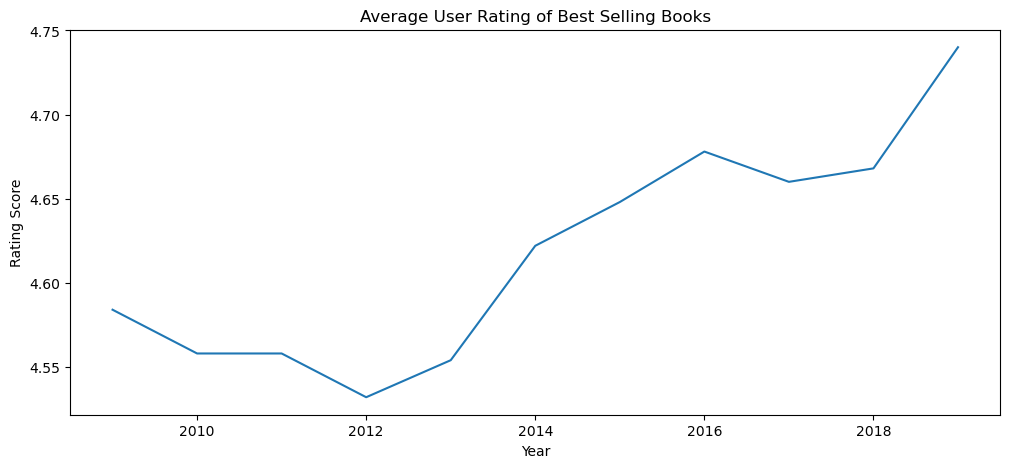

In [94]:
fig, ax = plt.subplots(figsize=(12,5))
plt.plot(df_year_avg_price_rating['Year'], df_year_avg_price_rating['User_Rating'])
plt.title('Average User Rating of Best Selling Books')
plt.xlabel('Year')
plt.ylabel('Rating Score')
plt.show()